## Checking GPU

In [3]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Importing Libraries


In [4]:
import os
import time
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from pathlib import Path
from collections import Counter, defaultdict

from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image

These imported modules enable us to accomplish the following key tasks:

1.  Effectively load and structure our data.
2.  Construct Convolutional Neural Network (CNN) architectures.
3.  Execute training and assessment processes for our models.
4.  Generate clear and informative visual representations of our findings.

## Mount Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset Extraction
Since the unarchiving process is a one-time operation, it can be executed once and then commented out.

In [6]:
# zip_path = "/content/drive/Shareddrives/AI and ML Final CourseWork/Scene Classification-20260421T071736Z-3-001.zip"
# extract_path = "/content/drive/Shareddrives/AI and ML Final CourseWork"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Dataset extracted successfully!")

## Setting the Dataset path

In [7]:
base_dir = Path("/content/drive/Shareddrives/AI and ML Final CourseWork/Scene Classification")
train_dir = base_dir / "train"
test_dir = base_dir / "test"

print("Train directory exists:", train_dir.exists())
print("Test directory exists:", test_dir.exists())

#Showing the path of the dataset
print("Train path:", train_dir)
print("Test path:", test_dir)

Train directory exists: True
Test directory exists: True
Train path: /content/drive/Shareddrives/AI and ML Final CourseWork/Scene Classification/train
Test path: /content/drive/Shareddrives/AI and ML Final CourseWork/Scene Classification/test


## Analyzing the Dataset Layout

In [8]:
train_counts = {}
test_counts = {}

for class_name in sorted(os.listdir(train_dir)):
    class_path = train_dir / class_name
    if class_path.is_dir():
        train_counts[class_name] = len(list(class_path.glob("*.jpg")))

for class_name in sorted(os.listdir(test_dir)):
    class_path = test_dir / class_name
    if class_path.is_dir():
        test_counts[class_name] = len(list(class_path.glob("*.jpg")))

print("Training class counts:")
print(train_counts)

print("\nTesting class counts:")
print(test_counts)

print("\nTotal train images:", sum(train_counts.values()))
print("Total test images:", sum(test_counts.values()))
print("Number of classes:", len(train_counts))

Training class counts:
{'buildings': 2184, 'forest': 2264, 'glacier': 2397, 'mountain': 2505, 'sea': 2267, 'street': 2375}

Testing class counts:
{'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}

Total train images: 13992
Total test images: 3000
Number of classes: 6


## Plot Class Distribution Visual


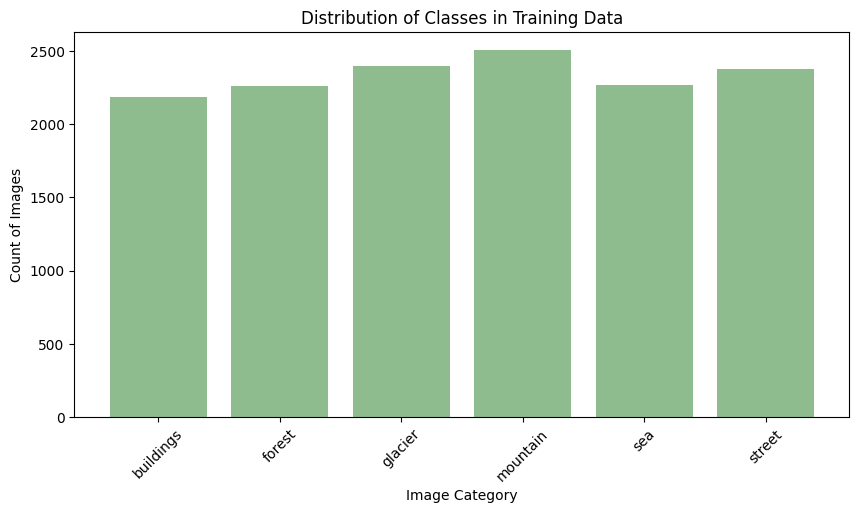

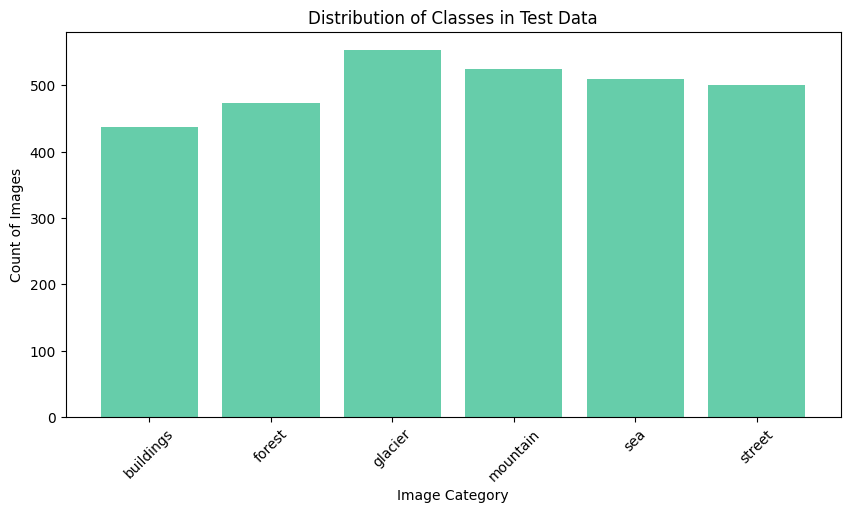

In [9]:
plt.figure(figsize=(10,5))
plt.bar(train_counts.keys(), train_counts.values(), color='darkseagreen')
plt.title("Distribution of Classes in Training Data")
plt.xlabel("Image Category")
plt.ylabel("Count of Images")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(test_counts.keys(), test_counts.values(), color='mediumaquamarine')
plt.title("Distribution of Classes in Test Data")
plt.xlabel("Image Category")
plt.ylabel("Count of Images")
plt.xticks(rotation=45)
plt.show()

This visualization offers a refined and presentable graphic suitable for reports or proposals.

## Displaying Exemplar Images from Each Category

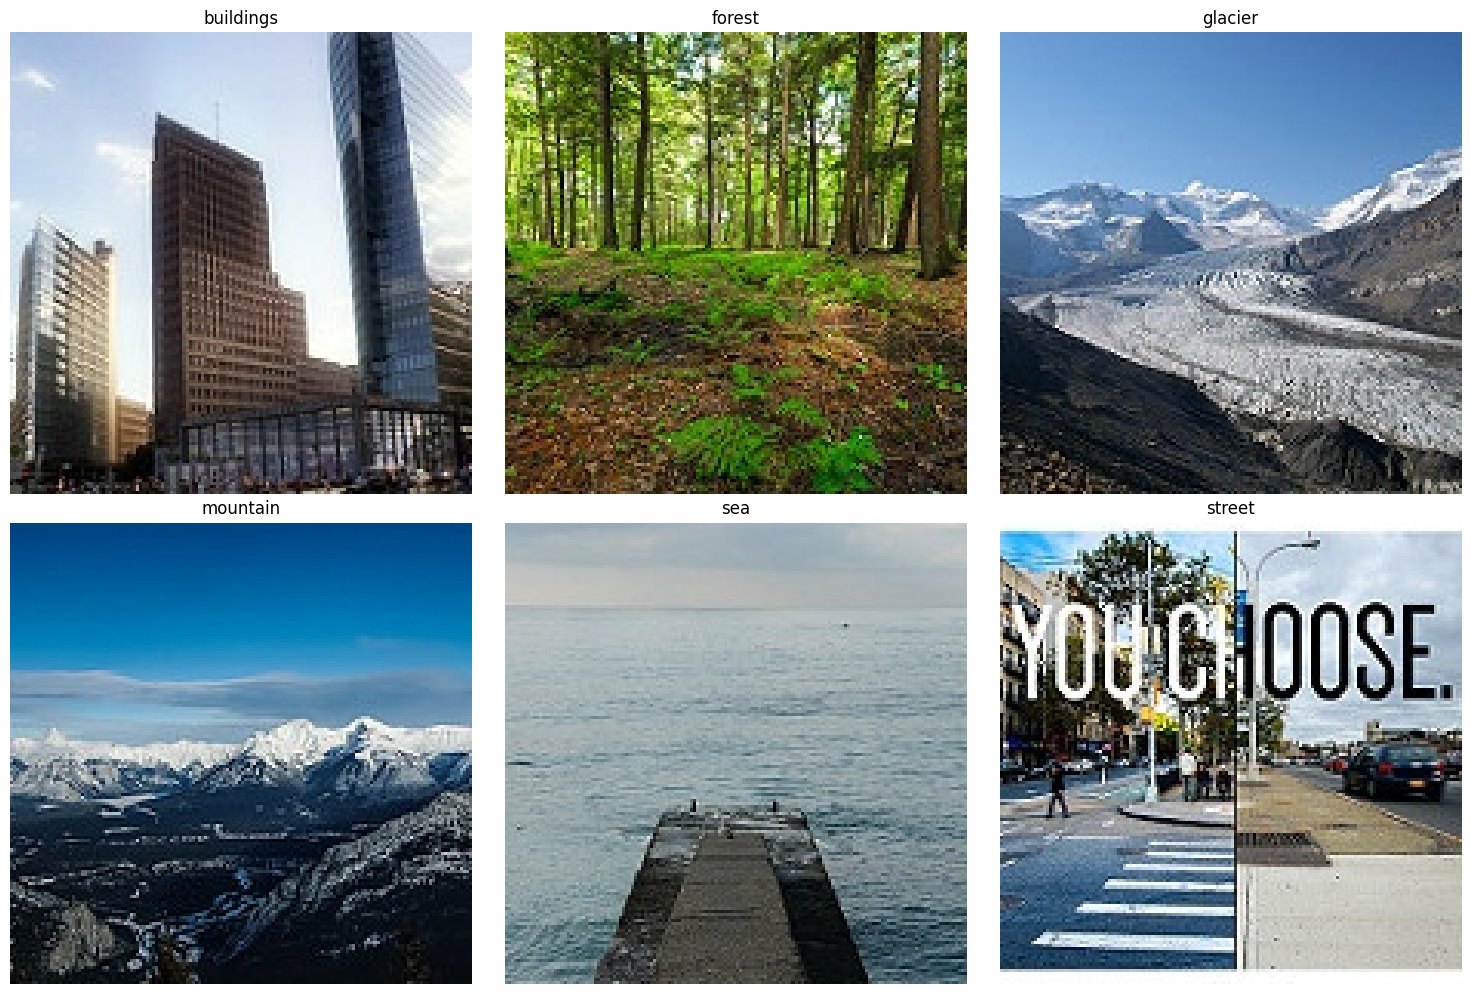

In [10]:
class_names = sorted(train_counts.keys())

plt.figure(figsize=(15,10))

for i, class_name in enumerate(class_names):
    class_path = train_dir / class_name
    img_path = random.choice(list(class_path.glob("*.jpg")))
    img = plt.imread(img_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

This section illustrates the actual appearance of images within each class.

## Verification for Corrupted or Invalid Files in Both Training and Testing Sets

In [11]:
from PIL import Image
import os

def find_invalid_images(directory):
    bad_files = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.load()
            except Exception as e:
                bad_files.append((file_path, str(e)))

    return bad_files

In [12]:
bad_train = find_invalid_images(train_dir)
bad_test = find_invalid_images(test_dir)

print("Invalid images in TRAIN:", len(bad_train))
for f, err in bad_train[:20]:
    print(f, " --> ", err)

print("\nInvalid images in TEST:", len(bad_test))
for f, err in bad_test[:20]:
    print(f, " --> ", err)

Invalid images in TRAIN: 0

Invalid images in TEST: 0


## Assessing Class Imbalance in the Datasets

In [13]:
import os

# Dictionary to store class counts
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

        class_counts[class_name] = len(images)  # Count images in each class

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>20}")
print("=" * 45)

for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>20}")

print("=" * 45)


Class Distribution:
Class Name                  Valid Image Count
buildings                                2184
forest                                   2264
glacier                                  2397
mountain                                 2505
sea                                      2267
street                                   2375


## Generating Training, Validation, and Testing Datasets

Given that we have separate training and testing directories, we will now subdivide the training folder into an 80% training set and a 20% validation set.

In [14]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 13992 files belonging to 6 classes.
Using 11194 files for training.
Found 13992 files belonging to 6 classes.
Using 2798 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


## Image Normalization and Pipeline Optimization

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)

Typically, pixel intensity values range from 0 to 255. Post-normalization, these values are scaled to a 0 to 1 range, which significantly enhances model training stability.

## Data Augmentation Techniques

In [16]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

## Visualizing Augmented Images

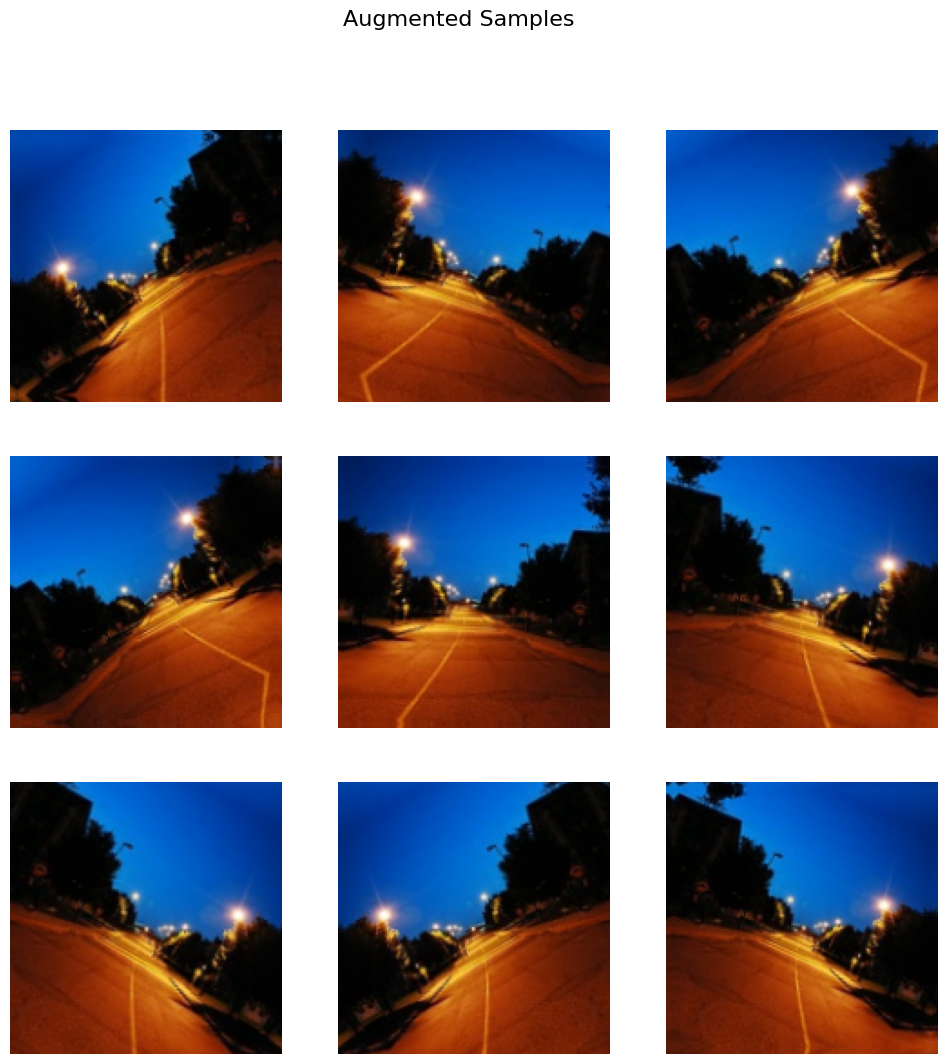

In [17]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 12))
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0])
        plt.axis("off")
    plt.suptitle("Augmented Samples", fontsize=16)
    plt.show()

This section clearly demonstrates the application of data augmentation.

# Constructing a Baseline CNN from Scratch

## Development of the Baseline CNN

Following the specified guidelines:

1.  Incorporates three convolutional layers.
2.  Each convolutional layer is succeeded by a pooling operation.
3.  Features three fully connected (dense) layers.
4.  Includes an output layer dedicated to classification.

In [18]:
baseline_model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,604,998 (36.64 MB)

 Trainable params: 9,604,998 (36.64 MB)

 Non-trainable params: 0 (0.00 B)

## Compilation of the Baseline Model

In [19]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

1.  `sparse_categorical_crossentropy` is an appropriate loss function as the labels are represented by integers.

2.  The required evaluation metrics include accuracy, precision, and recall.

## Training the Baseline Model

In [20]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)
0
start_time = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

baseline_train_time = time.time() - start_time
print(f"Baseline training time: {baseline_train_time:.2f} seconds")

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 70s 173ms/step - accuracy: 0.5670 - loss: 1.0987 - val_accuracy: 0.6683 - val_loss: 0.9257 - learning_rate: 0.0010
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6876 - loss: 0.8419 - val_accuracy: 0.7320 - val_loss: 0.7550 - learning_rate: 0.0010
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7393 - loss: 0.7227 - val_accuracy: 0.7555 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7654 - loss: 0.6584 - val_accuracy: 0.7941 - val_loss: 0.5927 - learning_rate: 0.0010
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.7849 - loss: 0.5997 - val_accuracy: 0.7795 - val_loss: 0.6440 - learning_rate: 0.0010
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7953 - loss: 0.5665 - val_accuracy: 0.7845 - val_loss: 0.6157 - learning_rate: 0.0010
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.8094 - 

This setup is crucial for several reasons:

1.  `EarlyStopping` prevents excessive training iterations, which helps mitigate overfitting.

2.  `ReduceLROnPlateau` dynamically adjusts the learning rate downwards when performance improvement plateaus.

## Visualization of Training Progress

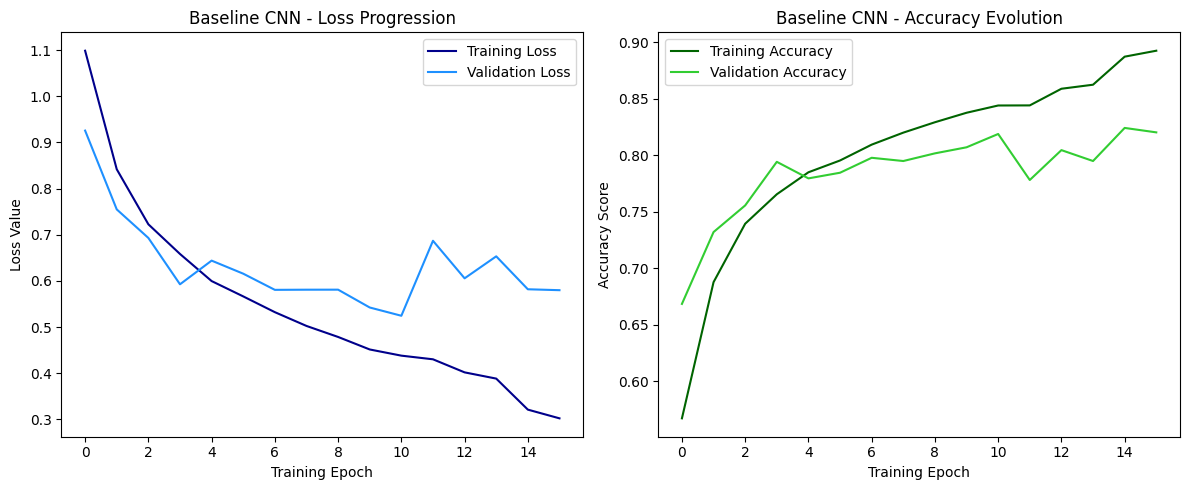

In [21]:
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Training Loss', color='darkblue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='dodgerblue')
    plt.title(f'{title} - Loss Progression')
    plt.xlabel('Training Epoch')
    plt.ylabel('Loss Value')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Training Accuracy', color='darkgreen')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='limegreen')
    plt.title(f'{title} - Accuracy Evolution')
    plt.xlabel('Training Epoch')
    plt.ylabel('Accuracy Score')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline CNN")

## Assessment of the Baseline Model

In [22]:
baseline_results = baseline_model.evaluate(test_ds, verbose=1)
print("Baseline test results:", baseline_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.8160 - loss: 0.5417
Baseline test results: [0.5417216420173645, 0.8159999847412109]


## Generating Classification Report and Confusion Matrix

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

   buildings       0.76      0.83      0.79       437
      forest       0.97      0.95      0.96       474
     glacier       0.88      0.63      0.73       553
    mountain       0.73      0.82      0.77       525
         sea       0.76      0.84      0.80       510
      street       0.85      0.85      0.85       501

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.81      3000



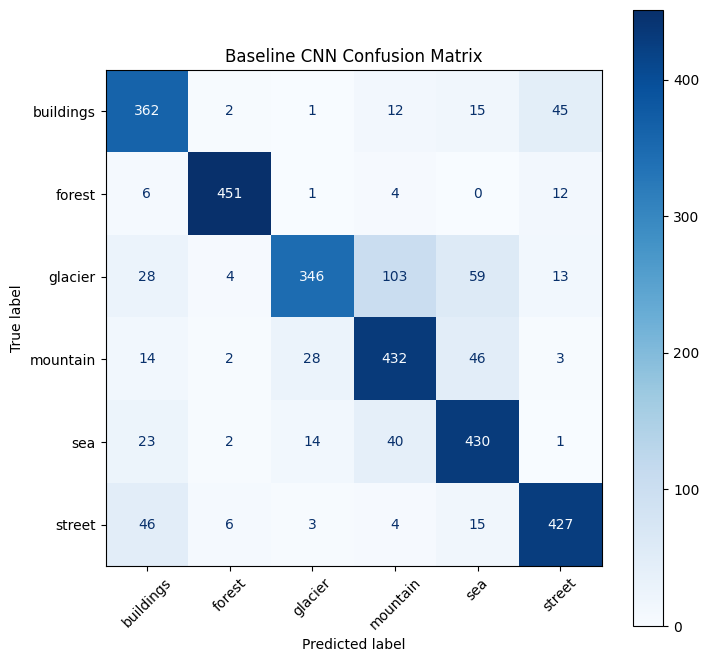

In [23]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = baseline_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Baseline CNN Confusion Matrix")
plt.show()

This section provides essential metrics such as the F1-score, a detailed confusion matrix, and precision values.

## Performing Predictions on a Sample Test Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


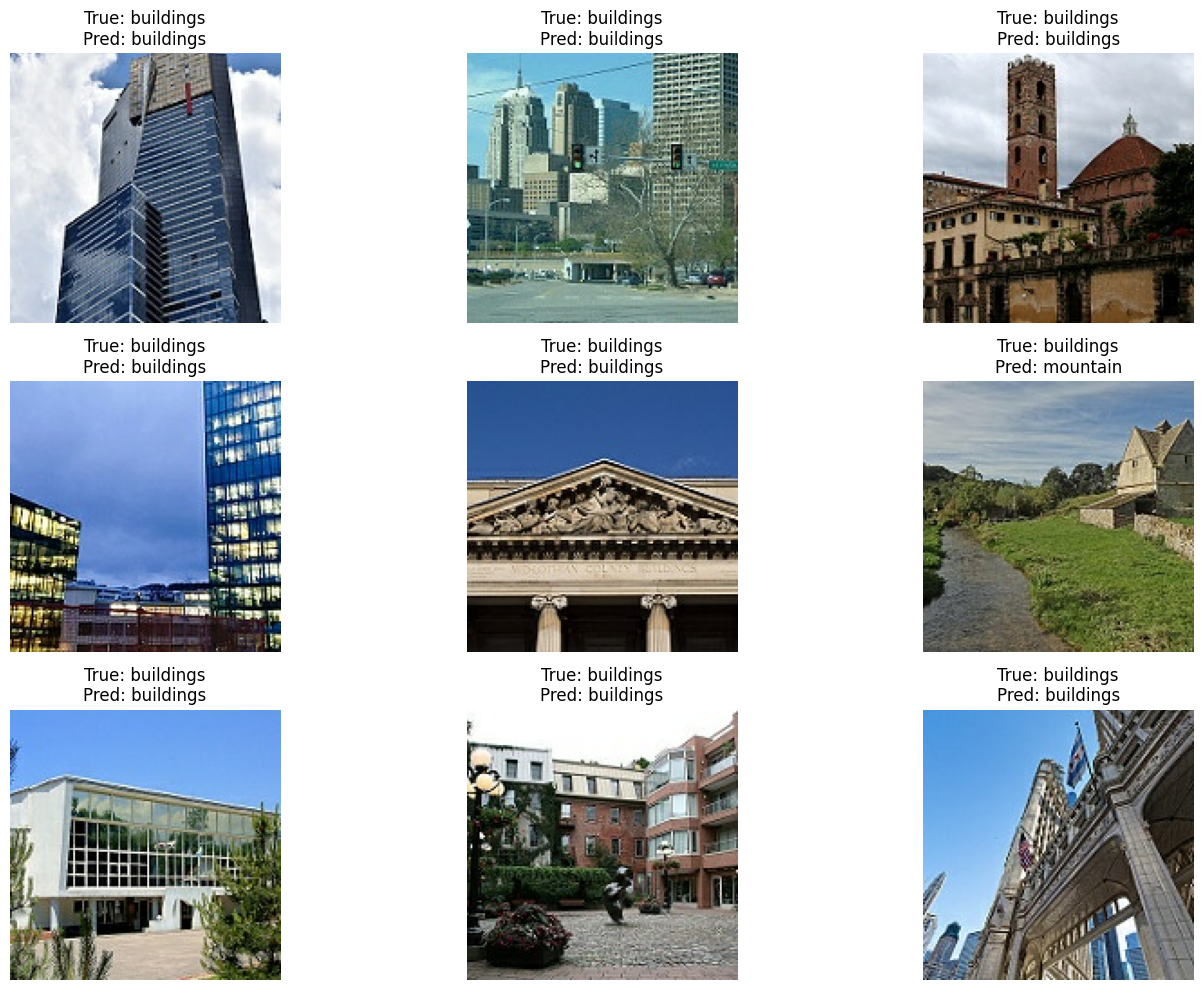

In [24]:
for images, labels in test_ds.take(1):
    preds = baseline_model.predict(images)
    pred_classes = np.argmax(preds, axis=1)

    plt.figure(figsize=(15,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        true_label = class_names[labels[i]]
        pred_label = class_names[pred_classes[i]]
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Enhanced CNN with Regularization Techniques

The requirements stipulate that the advanced model should incorporate at least twice the number of layers compared to the baseline and include regularization methods such as Batch Normalization and Dropout.

## Constructing the Deeper CNN

In [25]:
def build_deeper_model(dropout_rate=0.5, optimizer='adam'):
    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),
        data_augmentation,

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

deeper_model_adam = build_deeper_model(dropout_rate=0.5, optimizer='adam')
deeper_model_adam.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 10,946,534 (41.76 MB)

 Trainable params: 10,946,086 (41.76 MB)

 Non-trainable params: 448 (1.75 KB)

This is significant because this model is characterized by greater depth and increased computational power. Furthermore, the inclusion of regularization layers effectively aids in mitigating overfitting.

## Training the Deeper Model with Adam Optimizer

In [26]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [27]:
start_time = time.time()

history_deeper_adam = deeper_model_adam.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

deeper_adam_train_time = time.time() - start_time
print(f"Deeper model (Adam) training time: {deeper_adam_train_time:.2f} seconds")

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 52s 126ms/step - accuracy: 0.2165 - loss: 2.3839 - val_accuracy: 0.2445 - val_loss: 1.7165 - learning_rate: 0.0010
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.2424 - loss: 1.7567 - val_accuracy: 0.2166 - val_loss: 1.7618 - learning_rate: 0.0010
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.2490 - loss: 1.7269
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.2428 - loss: 1.7272 - val_accuracy: 0.2302 - val_loss: 3.6461 - learning_rate: 0.0010
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.2493 - loss: 1.7179 - val_accuracy: 0.2770 - val_loss: 1.6254 - learning_rate: 5.0000e-04
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.2703 - loss: 1.6442 - val_accuracy: 0.2931 - val_loss: 1.5865 - learning_rate: 5.0000e-04
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accurac

## Visualizing the History of the Deeper Model

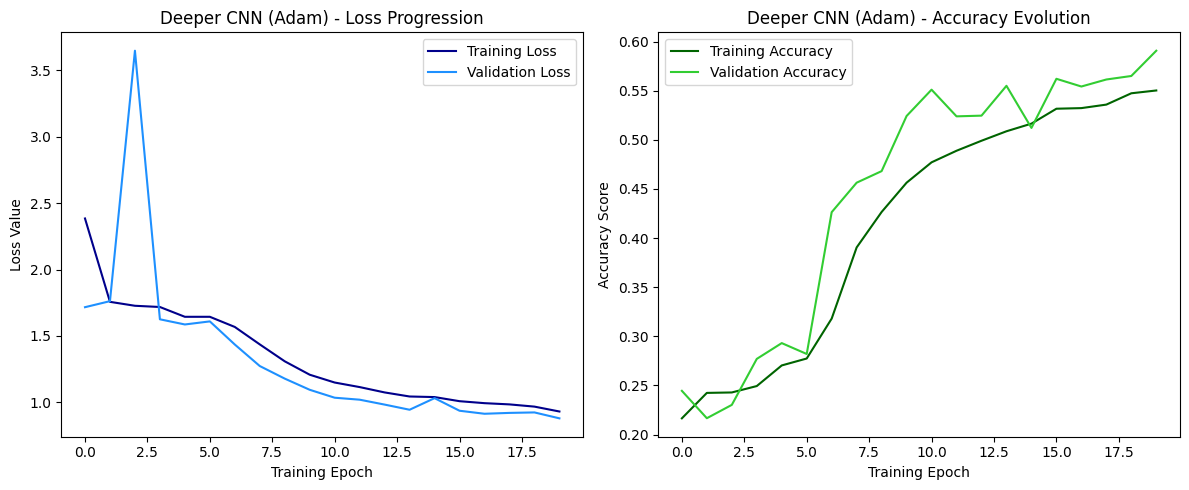

In [28]:
plot_history(history_deeper_adam, "Deeper CNN (Adam)")

## Evaluating the Deeper Model with Adam Optimizer

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5953 - loss: 0.8760
Deeper CNN (Adam) test results: [0.8760471940040588, 0.5953333377838135]
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
              precision    recall  f1-score   support

   buildings       0.67      0.80      0.73       437
      forest       0.92      0.96      0.94       474
     glacier       0.38      0.86      0.52       553
    mountain       0.49      0.20      0.29       525
         sea       0.24      0.01      0.02       510
      street       0.83      0.79      0.81       501

    accuracy                           0.60      3000
   macro avg       0.59      0.60      0.55      3000
weighted avg       0.57      0.60      0.54      3000



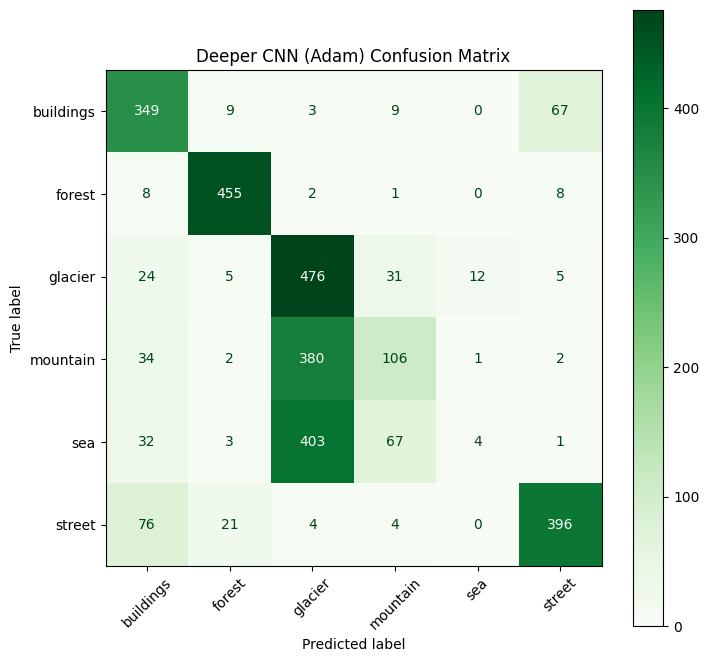

In [29]:
deeper_adam_results = deeper_model_adam.evaluate(test_ds, verbose=1)
print("Deeper CNN (Adam) test results:", deeper_adam_results)

y_pred_probs_deeper = deeper_model_adam.predict(test_ds)
y_pred_deeper = np.argmax(y_pred_probs_deeper, axis=1)

print(classification_report(y_true, y_pred_deeper, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_deeper)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Greens', xticks_rotation=45)
plt.title("Deeper CNN (Adam) Confusion Matrix")
plt.show()

# Comparative Analysis of Optimizers: SGD vs. Adam

## Training the Deeper Model with SGD Optimizer

In [30]:
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

deeper_model_sgd = build_deeper_model(dropout_rate=0.5, optimizer=sgd_optimizer)

In [31]:
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

deeper_model_sgd = build_deeper_model(dropout_rate=0.5, optimizer=sgd_optimizer)

start_time = time.time()

history_deeper_sgd = deeper_model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

deeper_sgd_train_time = time.time() - start_time
print(f"Deeper model (SGD) training time: {deeper_sgd_train_time:.2f} seconds")

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 42s 112ms/step - accuracy: 0.2367 - loss: 1.9417 - val_accuracy: 0.3649 - val_loss: 1.5905 - learning_rate: 0.0100
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3400 - loss: 1.5267
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
350/350 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - accuracy: 0.3647 - loss: 1.4552 - val_accuracy: 0.5029 - val_loss: 1.2263 - learning_rate: 0.0100
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - accuracy: 0.4600 - loss: 1.2564 - val_accuracy: 0.5747 - val_loss: 1.1313 - learning_rate: 0.0050
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.4829 - loss: 1.2308
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
350/350 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.4868 - loss: 1.2189 - val_accuracy: 0.5575 - val_loss: 1.1121 - learning_rate: 0.0050
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - accuracy: 0.5281 -

## Evaluation of the SGD Model

In [32]:
deeper_sgd_results = deeper_model_sgd.evaluate(test_ds, verbose=1)
print("Deeper CNN (SGD) test results:", deeper_sgd_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3693 - loss: 1.5927
Deeper CNN (SGD) test results: [1.5927358865737915, 0.36933332681655884]


# Ablation Study

The instructions require the removal of a specific component, such as dropout, to observe its impact on performance.

## Training a Model Without Dropout

In [33]:
ablation_model = build_deeper_model(dropout_rate=0.0, optimizer='adam')


In [34]:
ablation_model = build_deeper_model(dropout_rate=0.0, optimizer='adam')

start_time = time.time()

history_ablation = ablation_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

ablation_train_time = time.time() - start_time
print(f"Ablation model training time: {ablation_train_time:.2f} seconds")

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step - accuracy: 0.5057 - loss: 1.5658 - val_accuracy: 0.4464 - val_loss: 1.5325 - learning_rate: 0.0010
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.6455 - loss: 0.9327 - val_accuracy: 0.6994 - val_loss: 0.7976 - learning_rate: 0.0010
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.7093 - loss: 0.7815 - val_accuracy: 0.6951 - val_loss: 0.8358 - learning_rate: 0.0010
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7432 - loss: 0.7032
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.7437 - loss: 0.6975 - val_accuracy: 0.6162 - val_loss: 0.9809 - learning_rate: 0.0010
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.7916 - loss: 0.5800 - val_accuracy: 0.8202 - val_loss: 0.5231 - learning_rate: 5.0000e-04
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0

## Evaluating the Ablation Model

In [35]:
ablation_results = ablation_model.evaluate(test_ds, verbose=1)
print("Ablation model test results:", ablation_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8440 - loss: 0.4551
Ablation model test results: [0.4550802409648895, 0.843999981880188]


# Section B: Transfer Learning Approach

Utilizing a pre-trained model and assessing its performance against models developed from scratch.

MobileNetV2 stands out as an excellent choice for our dataset due to several advantages:

1.  It offers a more lightweight and faster architecture compared to alternatives like ResNet or VGG.

2.  It demonstrates strong performance with natural scene imagery.

3.  It is straightforward to fine-tune within the Colab environment.

## Reconfiguring Datasets for MobileNetV2 Input Dimensions

In [36]:
import tensorflow as tf

IMG_SIZE_TL = (224, 224)

train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE
)

test_ds_tl = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 13992 files belonging to 6 classes.
Using 11194 files for training.
Found 13992 files belonging to 6 classes.
Using 2798 files for validation.
Found 3000 files belonging to 6 classes.


## Preprocessing for MobileNetV2 Compatibility

In [37]:
# from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

# train_ds_tl = train_ds_tl.map(lambda x, y: (preprocess_input(x), y))
# val_ds_tl = val_ds_tl.map(lambda x, y: (preprocess_input(x), y))
# test_ds_tl = test_ds_tl.map(lambda x, y: (preprocess_input(x), y))

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

## Constructing the Transfer Learning Model

In [39]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras import models, layers

# Ensure num_classes is defined for this model
# Using train_ds_tl which is specific to transfer learning and should be available
class_names = train_ds_tl.class_names
num_classes = len(class_names)

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

transfer_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

This phase is crucial as it represents the feature extraction process:

1.  The convolutional base is kept frozen.
2.  Only the newly added classifier layers undergo training.

## Training the Transfer Learning Model

In [40]:
start_time = time.time()

history_transfer = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

transfer_train_time = time.time() - start_time
print(f"Transfer learning training time: {transfer_train_time:.2f} seconds")

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 132s 287ms/step - accuracy: 0.6780 - loss: 0.8306 - val_accuracy: 0.7706 - val_loss: 0.6212 - learning_rate: 0.0010
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 163ms/step - accuracy: 0.7518 - loss: 0.6591 - val_accuracy: 0.7798 - val_loss: 0.5921 - learning_rate: 0.0010
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 160ms/step - accuracy: 0.7650 - loss: 0.6119 - val_accuracy: 0.7884 - val_loss: 0.5802 - learning_rate: 0.0010
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 53s 153ms/step - accuracy: 0.7765 - loss: 0.5836 - val_accuracy: 0.7913 - val_loss: 0.5603 - learning_rate: 0.0010
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 83s 155ms/step - accuracy: 0.7853 - loss: 0.5672 - val_accuracy: 0.7906 - val_loss: 0.5577 - learning_rate: 0.0010
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 157ms/step - accuracy: 0.7904 - loss: 0.5531 - val_accuracy: 0.7938 - val_loss: 0.5490 - learning_rate: 0.0010
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 160ms/step - accuracy: 0.

## Fine-Tuning the Pre-Trained Model

In [41]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_finetune = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

finetune_train_time = time.time() - start_time
print(f"Fine-tuning training time: {finetune_train_time:.2f} seconds")

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 111s 257ms/step - accuracy: 0.6023 - loss: 1.2149 - val_accuracy: 0.7823 - val_loss: 0.6262 - learning_rate: 1.0000e-05
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7058 - loss: 0.7886
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
350/350 ━━━━━━━━━━━━━━━━━━━━ 70s 199ms/step - accuracy: 0.7195 - loss: 0.7487 - val_accuracy: 0.7756 - val_loss: 0.6432 - learning_rate: 1.0000e-05
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 85s 243ms/step - accuracy: 0.7530 - loss: 0.6489 - val_accuracy: 0.7734 - val_loss: 0.6422 - learning_rate: 5.0000e-06
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.7702 - loss: 0.6059
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
350/350 ━━━━━━━━━━━━━━━━━━━━ 73s 208ms/step - accuracy: 0.7732 - loss: 0.5925 - val_accuracy: 0.7720 - val_loss: 0.6418 - learning_rate: 5.0000e-06
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - 

This step is highly significant as it constitutes the actual fine-tuning process:

1.  Initially, the newly added top layers are trained.
2.  Subsequently, a portion of the pre-trained base model is unfrozen.
3.  A very small learning rate is employed to prevent detrimental alterations to the pre-existing features.

In [42]:
from sklearn.metrics import classification_report

y_true_tl = np.concatenate([y for x, y in test_ds_tl], axis=0)
y_pred_probs_tl = transfer_model.predict(test_ds_tl)
y_pred_tl = np.argmax(y_pred_probs_tl, axis=1)

print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

94/94 ━━━━━━━━━━━━━━━━━━━━ 60s 545ms/step
              precision    recall  f1-score   support

   buildings       0.81      0.77      0.79       437
      forest       0.91      0.97      0.94       474
     glacier       0.73      0.72      0.72       553
    mountain       0.62      0.76      0.68       525
         sea       0.73      0.69      0.71       510
      street       0.88      0.72      0.79       501

    accuracy                           0.77      3000
   macro avg       0.78      0.77      0.77      3000
weighted avg       0.78      0.77      0.77      3000



## Evaluating the Transfer Learning Model

In [43]:
transfer_results = transfer_model.evaluate(test_ds_tl, verbose=1)
print("Transfer learning / fine-tuned model test results:", transfer_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 422ms/step - accuracy: 0.7683 - loss: 0.6564
Transfer learning / fine-tuned model test results: [0.6563865542411804, 0.7683333158493042]


## Cross-Model Comparison

In [44]:
results_df = pd.DataFrame({
    "Architecture": [
        "Baseline CNN",
        "Deeper CNN (Adam)",
        "Deeper CNN (SGD)",
        "Ablation (No Dropout)",
        "Transfer Learning"
    ],
    "Validation Loss": [
        baseline_results[0],
        deeper_adam_results[0],
        deeper_sgd_results[0],
        ablation_results[0],
        transfer_results[0]
    ],
    "Prediction Accuracy": [
        baseline_results[1],
        deeper_adam_results[1],
        deeper_sgd_results[1],
        ablation_results[1],
        transfer_results[1]
    ],
    "Training Duration (s)": [
        baseline_train_time,
        deeper_adam_train_time,
        deeper_sgd_train_time,
        ablation_train_time,
        transfer_train_time + finetune_train_time
    ]
})

results_df = results_df.round(4)
results_df

,Architecture,Validation Loss,Prediction Accuracy,Training Duration (s)
0,Baseline CNN,0.5417,0.8160,230.7564
1,Deeper CNN (Adam),0.8760,0.5953,836.4884
2,Deeper CNN (SGD),1.5927,0.3693,276.9751
3,Ablation (No Dropout),0.4551,0.8440,873.2621
4,Transfer Learning,0.6564,0.7683,1072.6202


## Visualizing Model Comparisons

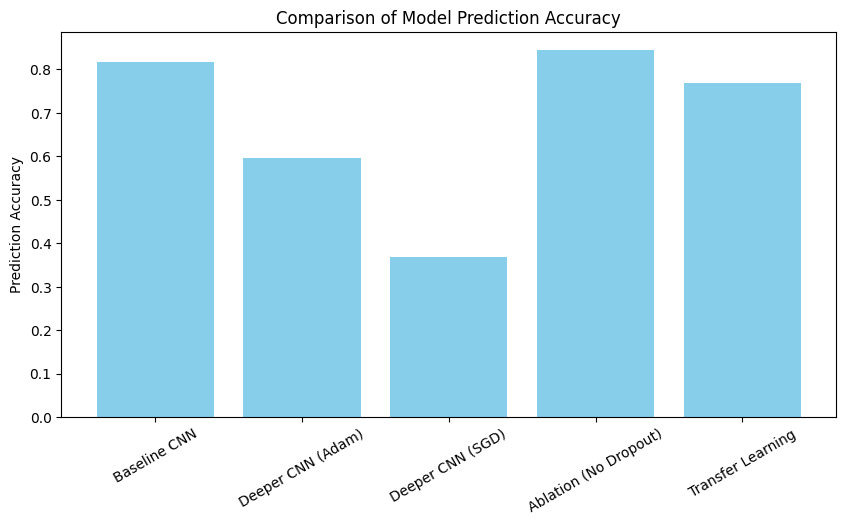

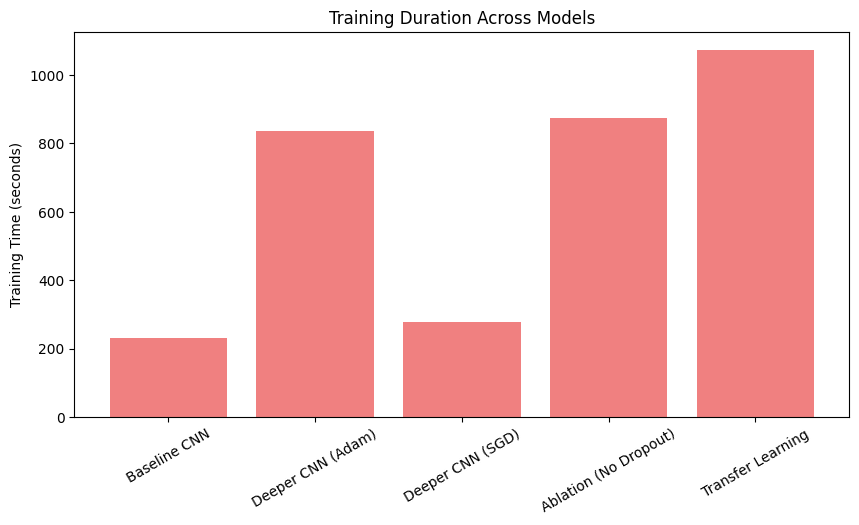

In [45]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Architecture"], results_df["Prediction Accuracy"], color='skyblue')
plt.title("Comparison of Model Prediction Accuracy")
plt.ylabel("Prediction Accuracy")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(results_df["Architecture"], results_df["Training Duration (s)"], color='lightcoral')
plt.title("Training Duration Across Models")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=30)
plt.show()